In [ ]:
from transformers import BartTokenizer, BartForConditionalGeneration, get_cosine_schedule_with_warmup
import torch
from models.TimexNormUtils import TemporalDataset, compute_metrics, collator

tokenizer = BartTokenizer.from_pretrained("facebook/bart-large")
model = BartForConditionalGeneration.from_pretrained("facebook/bart-large")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tokenizer.add_special_tokens({"additional_special_tokens": ["DCT:", "TYPE:", "TEXT:", "SPAN:"]})
model.resize_token_embeddings(len(tokenizer))

NUM_EPOCHS = 15
LR = 5e-5
WEIGHT_DECAY = 0.01
BATCH_SIZE = 8
MAX_NEW_TOK  = 64

cleandata_path = "D:\\GeoTKG\\cleandata\\normalise\\"
train = TemporalDataset(cleandata_path + "train.json")
eval = TemporalDataset(cleandata_path + "eval.json")
train_loader = torch.utils.data.DataLoader(train, batch_size=BATCH_SIZE, shuffle=True, collate_fn=lambda b: collator(b, tokenizer))
eval_loader = torch.utils.data.DataLoader(eval, batch_size=BATCH_SIZE, shuffle=False, collate_fn=lambda b: collator(b, tokenizer))

steps_per_epoch = len(train_loader)
eval_steps_per_epoch = len(eval_loader)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scaler = torch.amp.GradScaler(enabled=True)
sched = get_cosine_schedule_with_warmup(optimizer, num_warmup_steps=int(0.06*steps_per_epoch*NUM_EPOCHS), num_training_steps=steps_per_epoch*NUM_EPOCHS)

In [ ]:
history = {"loss": [], "eval_loss":[], "acc":[], "relax_acc":[], "lr":[]}
model.to(device)
for epoch in range(NUM_EPOCHS):
    model.train()
    total_loss = 0
    for step, batch in enumerate(train_loader):
        batch = {k: (v.to(device) if torch.is_tensor(v) else v) for k, v in batch.items()}
        with torch.amp.autocast(device_type="cuda", enabled=True):
            outputs = model(**batch)
            loss = outputs.loss
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad()
        sched.step()
        total_loss += loss.item()
        if step % 400 == 0:
            print(f"ep {epoch+((step+1)/steps_per_epoch):.2f} train_loss={(total_loss/(step+1)):.4f} lr={sched.get_last_lr()[0]:.6e}")

    model.eval()
    eval_loss = 0.0
    decoded_preds, decoded_labels = [], []

    with torch.no_grad():
        for batch in eval_loader:
            # keep a copy of labels for loss and for decoding ground truth
            labels_copy = batch["labels"].clone()
            batch = {k: v.to(device) for k, v in batch.items()}

            # loss
            out = model(**batch)
            eval_loss += out.loss.item()

            # predictions
            gen_ids = model.generate(
                input_ids=batch["input_ids"],
                attention_mask=batch["attention_mask"],
                max_new_tokens=MAX_NEW_TOK,
                num_beams=4,
                early_stopping=True
            )
            decoded_preds.extend(tokenizer.batch_decode(gen_ids, skip_special_tokens=True))
            labels_copy[labels_copy == -100] = tokenizer.pad_token_id
            decoded_labels.extend(tokenizer.batch_decode(labels_copy, skip_special_tokens=True))

    avg_eval_loss = eval_loss / max(1, len(eval_loader))
    metrics = compute_metrics(decoded_labels, decoded_preds)

    history["loss"].append(total_loss/steps_per_epoch)
    history["eval_loss"].append(avg_eval_loss)
    history["acc"].append(metrics["accuracy strict"])
    history["relax_acc"].append(metrics["accuracy relaxed"])
    history["lr"].append(sched.get_last_lr()[0])
    print(f"EPOCH: {epoch+1} LOSS: {total_loss/steps_per_epoch:.4f} ACC: {metrics['accuracy strict']} RACC: {metrics['accuracy relaxed']}")
    torch.save({'model_state_dict': model.state_dict()}, f"results/norm_model/time_norm_epoch{epoch+1}.pt")
        

d:\GeoTKG\venv\Lib\site-packages\torch\optim\lr_scheduler.py:182: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


ep 0.00 train_loss=4.5820 lr=3.113325e-08
ep 0.22 train_loss=1.3627 lr=1.248443e-05
ep 0.45 train_loss=0.9846 lr=2.493773e-05
ep 0.67 train_loss=0.8150 lr=3.739103e-05
ep 0.90 train_loss=0.7691 lr=4.984433e-05
ep 1.00 train_loss=1.6311 lr=4.999369e-05
ep 1.22 train_loss=0.5734 lr=4.993451e-05
ep 1.45 train_loss=0.5367 lr=4.981320e-05
ep 1.67 train_loss=0.5157 lr=4.963003e-05
ep 1.90 train_loss=0.5216 lr=4.938549e-05
ep 2.00 train_loss=0.4304 lr=4.925179e-05
ep 2.22 train_loss=0.4993 lr=4.891861e-05
ep 2.45 train_loss=0.5442 lr=4.852581e-05
ep 2.67 train_loss=0.5230 lr=4.807438e-05
ep 2.90 train_loss=0.4993 lr=4.756545e-05
ep 3.00 train_loss=0.0912 lr=4.731096e-05
ep 3.22 train_loss=0.5300 lr=4.672025e-05
ep 3.45 train_loss=0.4374 lr=4.607540e-05
ep 3.67 train_loss=0.3784 lr=4.537802e-05
ep 3.90 train_loss=0.3471 lr=4.462986e-05
ep 4.00 train_loss=0.1278 lr=4.426717e-05
ep 4.22 train_loss=1.3298 lr=4.344812e-05
ep 4.45 train_loss=1.0314 lr=4.258309e-05
ep 4.67 train_loss=0.7637 lr=4.167

In [5]:
model.save_pretrained("results/norm_model/hf/best")      # saves model + gen config
tokenizer.save_pretrained("results/norm_model/hf/best")

('results/norm_model/hf/best\\tokenizer_config.json',
 'results/norm_model/hf/best\\special_tokens_map.json',
 'results/norm_model/hf/best\\vocab.json',
 'results/norm_model/hf/best\\merges.txt',
 'results/norm_model/hf/best\\added_tokens.json')

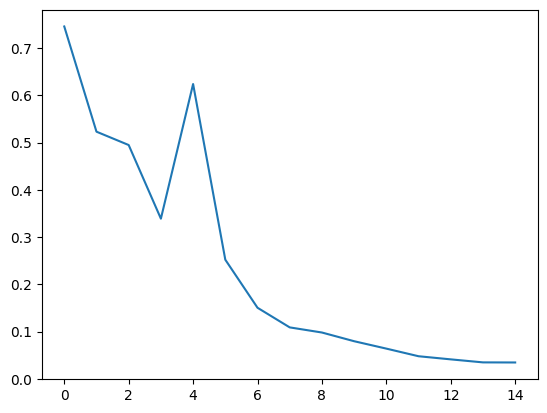

In [5]:
import matplotlib.pyplot as plt

plt.plot(history['loss'])
#plt.plot(history['eval_loss'])
plt.show()

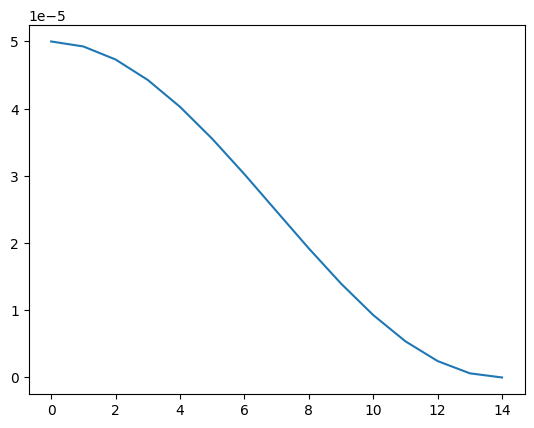

In [6]:
plt.plot(history['lr'])
plt.show()

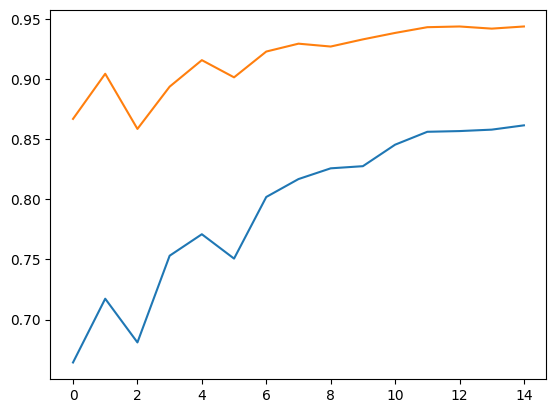

In [9]:
plt.plot(history['acc'])
plt.plot(history['relax_acc'])
plt.show()

In [7]:
import json
def get_test_data():
    examples = []
    path ="D:\\GeoTKG\\cleandata\\tie\\test.json"
    with open(path, "r") as f:
        examples=[json.loads(line) for line in f]
    return examples
test_data = get_test_data()

In [10]:
from copy import deepcopy
out = []
for sample in test_data:
    dct = [inst for inst in sample["instances"] if inst['id'] == 0 and inst['type'] != 'EVENT'][0]['value']
    for instance in sample["instances"]:
        if instance['type'] != 'EVENT' and instance['id'] != 0:
            text = deepcopy(sample['text'])
            sent_id = instance["sent_id"]
            mention = " ".join(text[sent_id][instance['offset'][0]:instance['offset'][1]])
            type_ = instance['type']

            out_text = [word for sent in text for word in sent]
            lens = [len(sent) for sent in text[:sent_id]]
            flat_loc_s = sum(lens)+instance['offset'][0]
            flat_loc_e = sum(lens)+instance['offset'][0]

            text = out_text[max(0, flat_loc_s-100):min(len(out_text), flat_loc_e+100)]

            text = " ".join([word for word in text])
            input_text = f'DCT: {dct} \nTYPE: {type_} \nTEXT: {text} \nSPAN: \"{mention}\"'
            out.append({'input_text':input_text, 'output_text':instance['value']})

In [16]:
cleandata_path = "D:\\GeoTKG\\cleandata\\normalise\\"
test = TemporalDataset(cleandata_path + "test.json")
test_loader = torch.utils.data.DataLoader(test, batch_size=BATCH_SIZE, shuffle=True, collate_fn=lambda b: collator(b, tokenizer))

model.eval()
test_loss = 0.0
decoded_preds, decoded_labels = [], []

with torch.no_grad():
    for batch in test_loader:
        # keep a copy of labels for loss and for decoding ground truth
        labels_copy = batch["labels"].clone()
        batch = {k: v.to(device) for k, v in batch.items()}

        # loss
        out = model(**batch)
        test_loss += out.loss.item()

        # predictions
        gen_ids = model.generate(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
            max_new_tokens=MAX_NEW_TOK,
            num_beams=4,
            early_stopping=True
        )
        decoded_preds.extend(tokenizer.batch_decode(gen_ids, skip_special_tokens=True))
        labels_copy[labels_copy == -100] = tokenizer.pad_token_id
        decoded_labels.extend(tokenizer.batch_decode(labels_copy, skip_special_tokens=True))

avg_test_loss = test_loss / max(1, len(test_loader))
metrics = compute_metrics(decoded_labels, decoded_preds)

In [17]:
avg_test_loss, metrics

(0.8508049110520859,
 {'accuracy strict': 0.813018506700702,
  'accuracy relaxed': 0.9368219527760051})